# HW 3: Ensembles

Student surname and name: **Kovtunyak Ivan**

----

Dear students,

This homework includes tasks on classification with ensemble methods (decision trees, random forest, gradient boosting, voting). Complete all tasks and submit the `.ipynb` file to **SmartLMS**. Make sure to include your surname and name in the filename.

Please pay attention, this is an individual work. Do not share your code with other students.

**Important note on LLM usage.** It is OK to consult with an LLM, but not just copying parts of the code without re-checking. If you use anything, try to show that you understand the meaning and the concepts you use. If your work contains a model output that contradicts your numbers, it can be understood that your task was done not by yourself.

**Per-student randomness.** This homework uses a per-student random seed derived from your name (see Task 1.1 helper cell). This means **your best hyperparameters and metric values will differ from your classmates'**

Don't delete task descriptions so I can see what code corresponds to what task. Run your code before sending — make sure it works without errors.

Each task brings up to 2 scores. You can get up to 10 scores in total.

Deadline: **23:59, 1 June**. Late submissions will not be accepted.

## Dataset

**TIMSS-Russia 8th-grade follow-up** — 4,399 students who took the TIMSS exam in 8th grade and reported what they were doing one year later. The goal is to **predict whether a student went on to vocational education** (primary or secondary vocational school) vs. continuing in general secondary school.

Drop `students.csv` into the same folder as this notebook.

**Required packages:** standard scientific stack (`numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`).

## Task 1. Data reading and preparation (0–2 scores)

### Task 1.1. Setup imports and per-student seed (helper — run this cell as-is)

The cell below derives a seed **deterministically from your name** and seeds NumPy / Python's random globally. **All `random_state` arguments later in the homework must reference `SEED`, not a hardcoded number like 42.** The auto-grader reproduces this seed from your name and re-checks your outputs.

In [1]:
# === Task 1.1 helper — run this cell as-is, do NOT edit anything below except STUDENT_NAME ===
import hashlib
import random
import numpy as np

STUDENT_NAME = "Kovtunyak Ivan Ivanovich"

# Lowercase + strip so capitalisation/leading-space typos don't change the seed.
_clean = STUDENT_NAME.strip().lower()
_placeholder = "write your full name here (latin, e.g. 'ivanov ivan ivanovich')" # Do not change this line!
if _clean == _placeholder or not _clean:
    raise ValueError("Set STUDENT_NAME to your full name before running this cell.")

SEED = int(hashlib.md5(_clean.encode()).hexdigest()[:8], 16)
random.seed(SEED)
np.random.seed(SEED)

print(f"STUDENT_NAME = {STUDENT_NAME!r}")
print(f"SEED         = {SEED}")

STUDENT_NAME = 'Kovtunyak Ivan Ivanovich'
SEED         = 193146654


### Task 1.2. Read the data

- Import standard libraries (`pandas`, `seaborn`, `matplotlib`, anything else you need).
- Read `students.csv` selecting the columns listed in the `cols` cell below. Save to `data`.
- Show `data.info()` and `data.head(10)`.

In [2]:
cols = ['idstud', 'bsmmat01', 'bsssci01', 'bsbg01', 'bsbg03', 'bsdage',
        'bsbgher', 'bsbgsbs', 'bsbgslm', 'bsbgsvm', 'bsbgscm', 'bsbgeml',
        'bsdgedup', 'bsdmwkhw', 'bcbg01', 'bcbg03a', 'bcbg05a',
        'schsc14q02', 'schsc22q01', 'schsc22q09', 'schsc22q11', 'schsc24q01',
        'schscmatedu', 'schsmratio', 'escs', 'pv1math', 'pv1read', 'pv1scie',
        'r9schooltype', 'a9q7', 'bQ1']

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter("ignore")
data = pd.read_csv("students.csv", usecols=cols)
data.info()
data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4399 entries, 0 to 4398
Data columns (total 31 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   idstud        4399 non-null   int64  
 1   bsmmat01      4399 non-null   float64
 2   bsssci01      4399 non-null   float64
 3   bsbg01        4398 non-null   float64
 4   bsbg03        4393 non-null   float64
 5   bsdage        4399 non-null   float64
 6   bsbgher       4395 non-null   float64
 7   bsbgsbs       4369 non-null   float64
 8   bsbgslm       4372 non-null   float64
 9   bsbgsvm       4379 non-null   float64
 10  bsbgscm       4374 non-null   float64
 11  bsbgeml       4373 non-null   float64
 12  bsdgedup      3923 non-null   float64
 13  bsdmwkhw      4319 non-null   float64
 14  bcbg01        4341 non-null   float64
 15  bcbg03a       4177 non-null   float64
 16  bcbg05a       4399 non-null   int64  
 17  schsc14q02    4286 non-null   float64
 18  schsc22q01    4362 non-null 

,idstud,bsmmat01,bsssci01,bsbg01,bsbg03,bsdage,bsbgher,bsbgsbs,bsbgslm,bsbgsvm,...,schsc24q01,schscmatedu,schsmratio,escs,pv1math,pv1read,pv1scie,r9schooltype,a9q7,bQ1
0,4340108,526.96272,508.82102,2.0,1.0,14.166667,8.91919,8.81989,9.60333,8.55351,...,3.0,-0.2560,68.667,-0.20,464.9556,499.5133,493.0436,1.0,4.0,4.0
1,4560308,645.47765,728.36052,2.0,1.0,15.416667,8.19314,8.81989,12.07123,10.35139,...,2.0,-1.0989,231.000,-0.14,522.8307,381.7076,507.7769,1.0,4.0,4.0
2,4460313,478.92826,575.32406,2.0,1.0,14.750000,10.92551,9.62932,8.60159,7.57539,...,2.0,0.5021,174.000,0.16,429.3582,477.8608,468.5192,1.0,4.0,4.0
3,5060206,546.33764,523.37781,1.0,1.0,14.500000,12.21628,13.03951,6.36452,8.20673,...,2.0,0.0872,135.333,0.42,481.7028,413.7601,450.3357,1.0,5.0,4.0
4,4800114,545.57841,551.25744,2.0,2.0,15.166667,10.04151,8.48873,9.96500,8.55351,...,3.0,-1.5162,144.667,-0.12,530.3864,413.7052,534.0731,1.0,3.0,2.0
5,4520119,556.14650,610.10064,2.0,1.0,15.000000,9.60097,8.48873,8.26761,7.27410,...,2.0,0.7756,145.778,-0.27,585.2236,551.1586,543.3980,2.0,3.0,4.0
6,3370116,610.16920,587.87069,1.0,1.0,15.166667,12.51743,10.19817,12.07123,8.55351,...,3.0,0.7756,90.500,0.63,529.9190,592.7182,537.1503,1.0,5.0,NaN
7,4240120,688.50332,672.70905,1.0,2.0,15.083333,14.01827,11.04872,13.46507,13.70742,...,1.0,-0.9168,166.909,0.99,665.6878,661.7437,604.1029,2.0,6.0,4.0
8,4400119,597.78968,655.37854,2.0,1.0,14.916667,10.25396,10.19817,10.35777,9.81093,...,2.0,-0.2560,155.500,0.36,557.1039,505.1269,537.5233,1.0,3.0,4.0
9,4740219,479.79129,498.14337,1.0,2.0,15.083333,10.92551,13.03951,9.60333,8.20673,...,2.0,-0.4184,120.667,0.66,343.9087,352.2805,355.9679,1.0,5.0,3.0


**Data description (raw columns):**

**Target:**
- `bQ1` — place of studying after grade 9: 1 = not studying, 2 = general secondary school, 3 = primary vocational school, 4 = secondary vocational school, 5 = other.

**Student-level features:**
- `bsmmat01` — math score in grade 8
- `bsssci01` — science score in grade 8
- `bsbg01` — sex (1=girl, 2=boy)
- `bsbg03` — language of test at home (1=always, 2=almost always, 3=sometimes, 4=never)
- `bsdage` — age
- `bsbgher` — home educational resources (composite index)
- `bsbgsbs` / `bsbgslm` / `bsbgsvm` / `bsbgscm` / `bsbgeml` — student-self-reported scales (Sense of Belonging, Like Learning Maths, Value Maths, Confident in Maths, Engaged in Maths Lessons)
- `bsdgedup` — parental education (4-level scale)
- `bsdmwkhw` — minutes spent on homework per week
- `pv1math` / `pv1read` / `pv1scie` — PISA-style plausible values (math/reading/science)
- `escs` — economic, social and cultural status (PISA composite)
- `a9q7` — student's plan to attend university (1=yes, 2=no, 3=don't know)
- `r9schooltype` — school type 1 year later (1=general, 2/3/4=other tracks)

**School-level features:**
- `bcbg01` / `bcbg03a` / `bcbg05a` — teacher background scales
- `schsc14q02` / `schsc22q01` / `schsc22q09` / `schsc22q11` / `schsc24q01` — school principal survey items
- `schscmatedu` — index of school math education quality
- `schsmratio` — student-math-teacher ratio

### Task 1.3. Recode variables

- `bQ1` (target): 1 and 5 → NaN; 2 → 0 (general); 3 and 4 → 1 (vocational). Print value counts after recoding.
- `bsbg03`: 1 → 0; 2, 3, 4 → 1. Print value counts.
- `bsdgedup`: 4 and 5 → 3 (cap at 3). Print value counts.
- `r9schooltype`: 1 → 0; 2, 3, 4 → 1. Print value counts.

In [3]:
data['bQ1'] = data['bQ1'].map({1: np.nan, 2: 0, 3: 1, 4: 1, 5: np.nan})
print(data['bQ1'].value_counts(dropna=False), '\n')

data['bsbg03'] = data['bsbg03'].map({1: 0, 2: 1, 3: 1, 4: 1})
print(data['bsbg03'].value_counts(dropna=False), '\n')

data['bsdgedup'] = data['bsdgedup'].replace({4: 3, 5: 3})
print(data['bsdgedup'].value_counts(dropna=False), '\n')

data['r9schooltype'] = data['r9schooltype'].map({1: 0, 2: 1, 3: 1, 4: 1})
print(data['r9schooltype'].value_counts(dropna=False))

bQ1
0.0    2527
1.0    1237
NaN     635
Name: count, dtype: int64 

bsbg03
0.0    3659
1.0     734
NaN       6
Name: count, dtype: int64 

bsdgedup
1.0    2079
2.0    1145
3.0     699
NaN     476
Name: count, dtype: int64 

r9schooltype
0.0    3389
1.0     935
NaN      75
Name: count, dtype: int64


### Task 1.4. Duplicates + missingness + imputation

- Print sum of duplicated rows. Delete if any.
- Drop rows where `bQ1` is NaN (we can't predict an unknown target).
- Show per-variable missing count, descending.
- Impute: categorical features with **most_frequent**, continuous with **mean** (use `SimpleImputer` from `sklearn.impute`).
- Print total NaN sum after imputation (must be 0).

In [4]:
features_cat = ['bsbg01', 'bsbg03', 'bsdgedup', 'bsdmwkhw', 'bcbg03a',
                'r9schooltype', 'schsc22q01', 'schsc22q09', 'schsc22q11', 'schsc24q01']
features_cnt = ['bsmmat01', 'bsssci01', 'bsdage', 'bsbgher', 'bsbgsbs',
                'bsbgslm', 'bsbgsvm', 'bsbgscm', 'bsbgeml', 'bcbg01',
                'schsc14q02', 'schscmatedu', 'schsmratio', 'escs',
                'pv1math', 'pv1read', 'pv1scie', 'a9q7']

from sklearn.impute import SimpleImputer
print("Duplicated rows:", data.duplicated().sum())
data = data.drop_duplicates()

data = data.dropna(subset=['bQ1']).reset_index(drop=True)

print(data.isna().sum().sort_values(ascending=False).head(20))

data[features_cat] = SimpleImputer(strategy='most_frequent').fit_transform(data[features_cat])
data[features_cnt] = SimpleImputer(strategy='mean').fit_transform(data[features_cnt])

print("Total NaN after imputation:", data[features_cat + features_cnt].isna().sum().sum())

Duplicated rows: 0
bsdgedup        396
schsmratio      266
bcbg03a         204
a9q7            118
schsc14q02       95
schscmatedu      69
bsdmwkhw         60
r9schooltype     58
schsc22q09       52
bcbg01           42
schsc22q01       35
escs             35
schsc24q01       32
bsbgsbs          23
bsbgslm          20
schsc22q11       19
bsbgeml          18
bsbgscm          16
bsbgsvm          13
bsbg03            6
dtype: int64
Total NaN after imputation: 0


## Task 2. Visualisation, feature selection, scoring choice, train/test split (0–2 scores)

### Task 2.1. Target distribution

Make a bar plot showing the count of class 0 (general school) and class 1 (vocational). Print the class balance (% of each class).

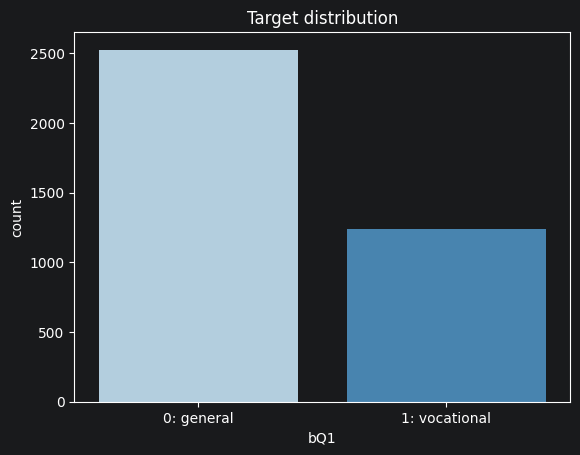

bQ1
0.0    67.14
1.0    32.86
Name: proportion, dtype: float64


In [5]:
ax = sns.countplot(x='bQ1', data=data, hue='bQ1', palette='Blues', legend=False)
ax.set_xticklabels(['0: general', '1: vocational'])
plt.title('Target distribution')
plt.show()

print((data['bQ1'].value_counts(normalize=True) * 100).round(2))

### Task 2.2. Feature–target correlations

- Build `X` (features only, drop `idstud` and `bQ1`) and `y` (the recoded `bQ1`).
- Compute `|correlation|` of each feature with `y`.
- Print the names of features with `|corr| < 0.05` (weak predictors).
- **Drop those features from `X`** (we will not use them in modelling).
- Make a **horizontal** bar plot of the remaining features' correlations with the target, sorted by absolute size.

Weak features (|corr| < 0.05): ['bsbgsbs', 'bsdmwkhw', 'bcbg05a', 'schsc14q02', 'schsc22q11', 'schsc24q01', 'schscmatedu', 'schsmratio']


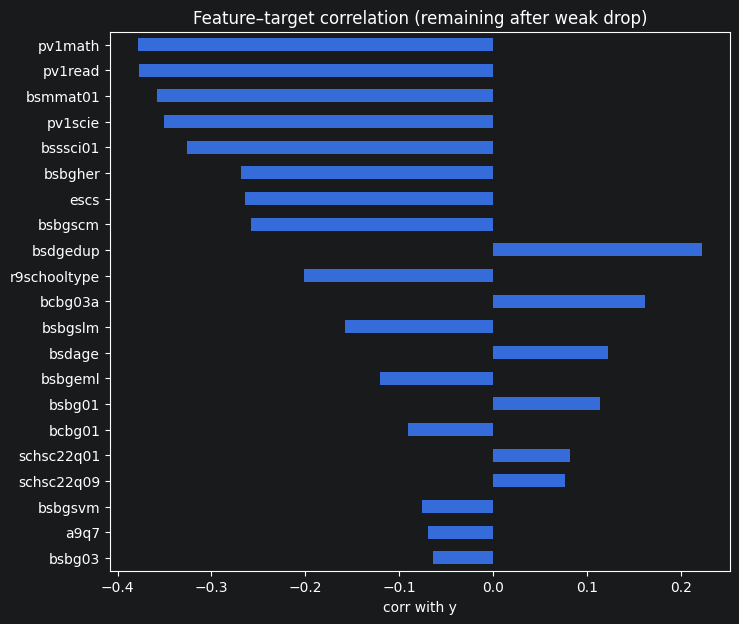

In [6]:
X = data.drop(columns=['idstud', 'bQ1'])
y = data['bQ1'].astype(int)

corr_y = X.corrwith(y)
weak = corr_y[corr_y.abs() < 0.05].index.tolist()
print("Weak features (|corr| < 0.05):", weak)
X = X.drop(columns=weak)

corr_left = X.corrwith(y)
order = corr_left.abs().sort_values().index
plt.figure(figsize=(8, 7))
corr_left.loc[order].plot(kind='barh')
plt.title('Feature–target correlation (remaining after weak drop)')
plt.xlabel('corr with y')
plt.show()

### Task 2.3. Feature–feature correlations (multicollinearity check)

- Build a correlation matrix of `X` (features only, no target).
- Print only the cells where `|corr| > 0.5` (mask the rest as NaN, exclude the trivial diagonal). This surfaces multicollinearity.
- **Drop these features from `X`**: `bsmmat01`, `bsssci01`, `pv1read`, `pv1scie`, `bsbgher`, `bsbgsbs`. (The first two are highly correlated with `pv1math`; the next two with each other and with the math/science scores; the last two with `escs`.)
- Print `X.shape` after the drops.

In [7]:
corr_matrix = X.corr()

mask = (corr_matrix.abs() > 0.5) & (corr_matrix.abs() < 1)

print(corr_matrix.where(mask).stack().round(2))

drop_multicol = ['bsmmat01', 'bsssci01', 'pv1read', 'pv1scie', 'bsbgher', 'bsbgsbs']
X = X.drop(columns=drop_multicol, errors='ignore')
print(f'X.shape: {X.shape}')

bsmmat01  bsssci01    0.79
          pv1math     0.66
          pv1read     0.57
          pv1scie     0.61
bsssci01  bsmmat01    0.79
          pv1math     0.62
          pv1read     0.55
          pv1scie     0.60
bsbgher   bsdgedup   -0.57
          escs        0.57
bsbgslm   bsbgsvm     0.54
          bsbgscm     0.60
          bsbgeml     0.65
bsbgsvm   bsbgslm     0.54
bsbgscm   bsbgslm     0.60
          bsbgeml     0.50
bsbgeml   bsbgslm     0.65
          bsbgscm     0.50
bsdgedup  bsbgher    -0.57
escs      bsbgher     0.57
pv1math   bsmmat01    0.66
          bsssci01    0.62
          pv1read     0.77
          pv1scie     0.84
pv1read   bsmmat01    0.57
          bsssci01    0.55
          pv1math     0.77
          pv1scie     0.82
pv1scie   bsmmat01    0.61
          bsssci01    0.60
          pv1math     0.84
          pv1read     0.82
dtype: float64
X.shape: (3764, 16)


### Task 2.4. Scoring metric — your choice + justification

The target is imbalanced (~67% general / ~33% vocational). Default `accuracy` is misleading: a trivial "always predict 0" classifier already scores ~67%. We need a better scoring metric for our `RandomizedSearchCV` runs in Tasks 3–5.

**Pick ONE** of the three metrics below and set it in the code cell. Then write a **3–5 sentence justification** in the markdown cell below explaining why this metric is appropriate for the application context: identifying which 8th-grade students are likely to take the vocational track, perhaps to plan support / counselling.

- `'recall'` — recall of the positive (vocational) class. Maximises catching all vocational-bound students at the cost of more false positives.
- `'f1'` — harmonic mean of precision and recall for class 1. Balances catching the positives against not over-flagging.
- `'balanced_accuracy'` — average of recall over both classes. Treats both error types symmetrically.

In [8]:
SCORING = 'f1'  # 'recall', 'f1', or 'balanced_accuracy'

assert SCORING in ('recall', 'f1', 'balanced_accuracy'), \
    "Set SCORING to one of: 'recall', 'f1', 'balanced_accuracy'"
print(f"Chosen scoring: {SCORING}")

Chosen scoring: f1


**Your justification (3–5 sentences):**
The target var is imbalanced - 67% general and 33% vocational. Accuracy is not a good metric here, as a model that always predicts the majority class (general) would achieve 67% accuracy without actually learning anything useful. Purpose of task is finding students who are likely to choose voccational education. There are important two types of model mistakes FN and FP.
So, F1 score balaces bboth of these errors through combining precision and recall into one metric, which makes it a fair choice for this task.


### Task 2.5. Stratified split

- Use `train_test_split` with `test_size=0.15`, `stratify=y`, `random_state=SEED`, `shuffle=True`.
- Print `X_train.shape`, `X_test.shape`.
- Print % vocational in `y_train` and % vocational in `y_test` (they should be close to the global ~33%).

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED, shuffle=True)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print(f"% vocational in train: {y_train.mean()*100:.2f}")
print(f"% vocational in test : {y_test.mean()*100:.2f}")

X_train: (3199, 16)  X_test: (565, 16)
% vocational in train: 32.85
% vocational in test : 32.92


## Task 3. Decision Tree classifier (0–2 scores)

### Task 3.1. RandomizedSearchCV for the tree

Use `DecisionTreeClassifier(random_state=SEED)`. Search:
- `max_depth` — integers in 1..50
- `max_features` — integers in 1..`X.shape[1]`
- `min_samples_leaf` — one of `[1, 5, 10, 25, 50]`
- `criterion` — one of `['gini', 'entropy']`

`RandomizedSearchCV` with `n_iter=50`, `cv=5`, `scoring=SCORING` (from Task 2.4), `n_jobs=-1`, `random_state=SEED`. Print `best_params_` and the best CV score.

> See `L5_Ensembles.ipynb` for the canonical pattern: build a `param_distributions` dict mapping each hyper-parameter name to a list/range of candidates, wrap it in `RandomizedSearchCV(estimator, param_distributions=..., n_iter=..., cv=..., scoring=..., random_state=...)`, call `.fit(X_train, y_train)`, then read `.best_params_` and `.best_score_`.*

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dt = {
    'max_depth':        range(1, 51),
    'max_features':     range(1, X.shape[1] + 1),
    'min_samples_leaf': [1, 5, 10, 25, 50],
    'criterion':        ['gini', 'entropy'],
}
search_dt = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    param_distributions=param_dt, n_iter=50, cv=5,
    scoring=SCORING, n_jobs=-1, random_state=SEED)
search_dt.fit(X_train, y_train)

best_params_dt = search_dt.best_params_
print("DT best params:", best_params_dt)
print(f"DT best CV {SCORING}: {search_dt.best_score_:.3f}")
#по результатам поиска дерево получилось небольшим, всего с 4 уровнями

DT best params: {'min_samples_leaf': 1, 'max_features': 8, 'max_depth': 4, 'criterion': 'gini'}
DT best CV f1: 0.554


### Task 3.2. Fit best tree + `fit_metrics` function

- Refit `DecisionTreeClassifier(**best_params_dt, random_state=SEED)` on `X_train`. Save it as `dt_best`.
- Build a function `fit_metrics(model, X_tr, y_tr, X_te, y_te, name)` that:
    - Prints `name`
    - Prints train accuracy and test accuracy
    - Prints `classification_report` on test
    - Plots the confusion matrix on test (use `ConfusionMatrixDisplay`)
- Call `fit_metrics(dt_best, X_train, y_train, X_test, y_test, 'Decision Tree')`.

This function will be reused in Tasks 4 and 5.

=== Decision Tree ===
Train accuracy: 0.737
Test  accuracy: 0.722
              precision    recall  f1-score   support

           0       0.80      0.79      0.79       379
           1       0.58      0.59      0.58       186

    accuracy                           0.72       565
   macro avg       0.69      0.69      0.69       565
weighted avg       0.72      0.72      0.72       565



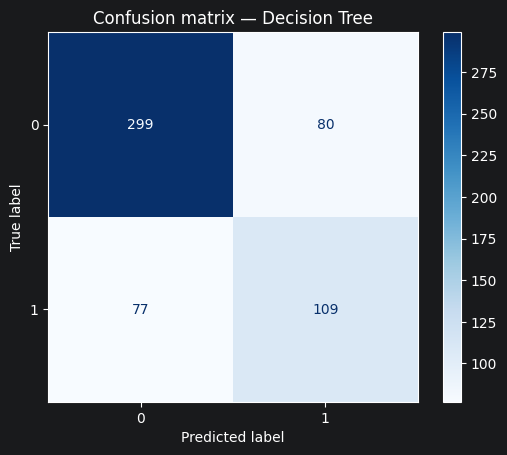

In [11]:
from sklearn.metrics import (accuracy_score, classification_report,
                             ConfusionMatrixDisplay, get_scorer)

scorer = get_scorer(SCORING)

def fit_metrics(model, X_tr, y_tr, X_te, y_te, name):
    train_acc = accuracy_score(y_tr, model.predict(X_tr))
    test_acc  = accuracy_score(y_te, model.predict(X_te))
    test_score = scorer(model, X_te, y_te)
    print(f"=== {name} ===")
    print(f"Train accuracy: {train_acc:.3f}")
    print(f"Test  accuracy: {test_acc:.3f}")
    print(classification_report(y_te, model.predict(X_te)))
    ConfusionMatrixDisplay.from_estimator(model, X_te, y_te, cmap='Blues')
    plt.title(f'Confusion matrix — {name}'); plt.show()
    return {'model': name, 'train_acc': train_acc,
            'test_acc': test_acc, f'test_{SCORING}': test_score}

dt_best = DecisionTreeClassifier(**best_params_dt, random_state=SEED).fit(X_train, y_train)
res_dt = fit_metrics(dt_best, X_train, y_train, X_test, y_test, 'Decision Tree')

#разрыв между train и test - незначительный, переобучения нет

### Task 3.3. Visualise the tree

Use `sklearn.tree.plot_tree` with: feature names, `max_depth=3`, `precision=2`, `filled=True`, sensible `figsize` and `fontsize`. Each node should show feature + threshold + gini + samples + class.

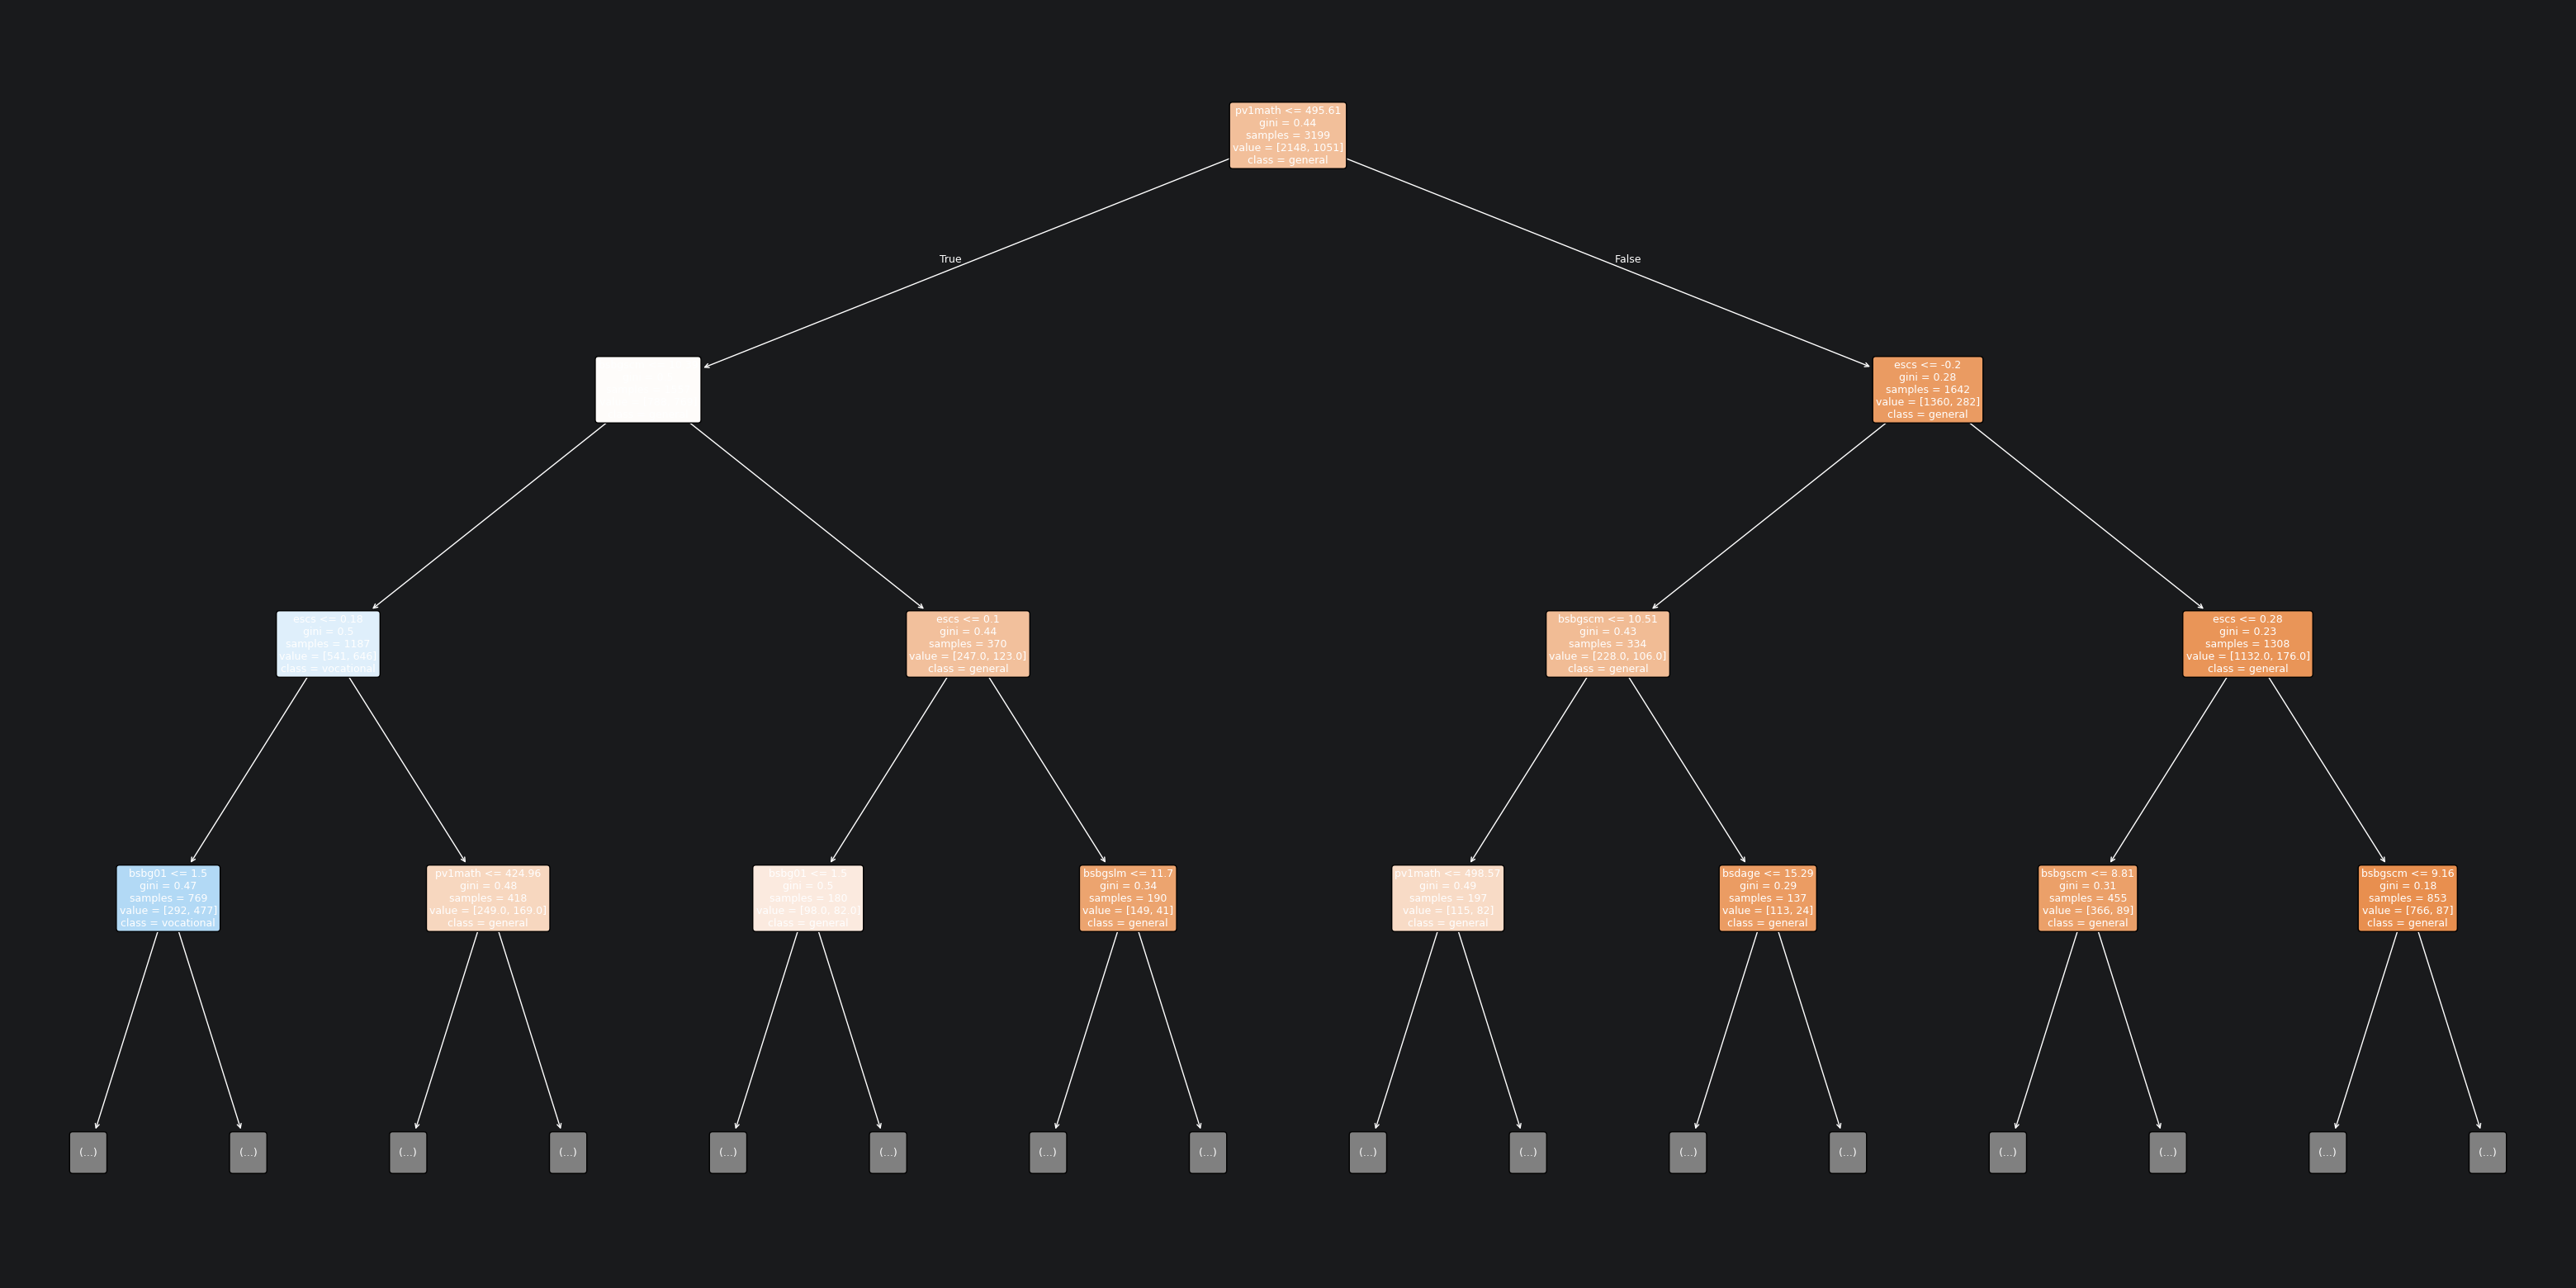

In [12]:
from sklearn.tree import plot_tree

plt.figure(figsize=(40,20))
plot_tree(dt_best, feature_names=X.columns.tolist(), class_names=['general', 'vocational'],
          max_depth=3, precision=2, filled=True, rounded=True, fontsize=9)
plt.show()
#наибольший вклад вносит pv1math

### Task 3.4. Feature importance

Horizontal bar plot of `dt_best.feature_importances_` with feature names, sorted descending.

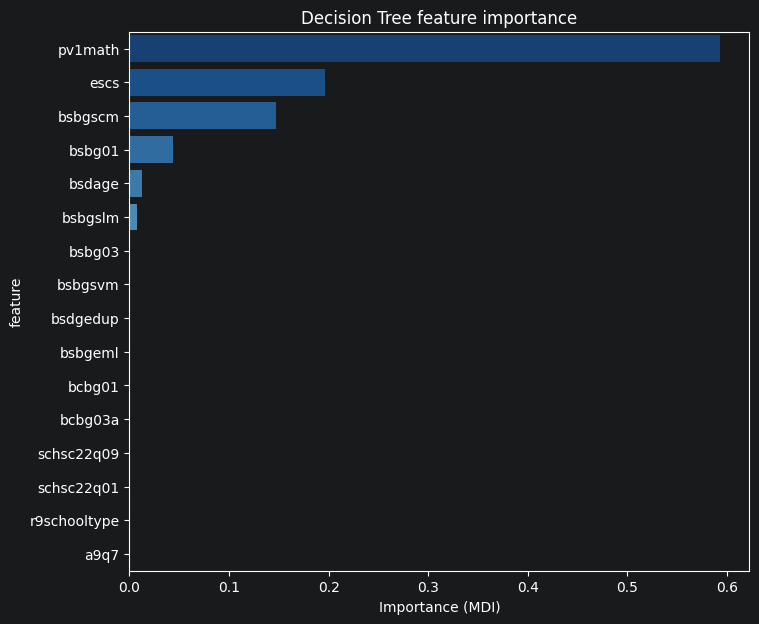

In [13]:
def plot_importance(model, columns, title):
    imp = (pd.DataFrame({'feature': columns, 'imp': model.feature_importances_})
           .sort_values('imp', ascending=False))
    plt.figure(figsize=(8, 7))
    sns.barplot(x='imp', y='feature', data=imp, hue='feature',
                palette='Blues_r', legend=False)
    plt.title(title); plt.xlabel('Importance (MDI)'); plt.show()
    return imp

imp_dt = plot_importance(dt_best, X.columns, 'Decision Tree feature importance')

#барплот показывает те же данные, что и дерево - самый влиятельный признак pv1math

## Task 4. Random Forest classifier (0–2 scores)

### Task 4.1. RandomizedSearchCV for RF

Use `RandomForestClassifier(random_state=SEED, n_jobs=-1)`. Search:
- `n_estimators` — one of `[100, 200, 400, 800]`
- `max_depth` — integers in 1..20
- `max_features` — integers in 1..`X.shape[1]`
- `min_samples_leaf` — one of `[1, 5, 10, 25]`

`RandomizedSearchCV` with `n_iter=30`, `cv=5`, `scoring=SCORING`, `n_jobs=-1`, `random_state=SEED`. Print `best_params_` and best CV score.

> See `L5_Ensembles.ipynb` for the canonical pattern: build a `param_distributions` dict mapping each hyper-parameter name to a list/range of candidates, wrap it in `RandomizedSearchCV(estimator, param_distributions=..., n_iter=..., cv=..., scoring=..., random_state=...)`, call `.fit(X_train, y_train)`, then read `.best_params_` and `.best_score_`.*

In [14]:
from sklearn.ensemble import RandomForestClassifier

param_rf = {
    'n_estimators':     [100, 200, 400, 800],
    'max_depth':        range(1, 21),
    'max_features':     range(1, X.shape[1] + 1),
    'min_samples_leaf': [1, 5, 10, 25],
}
search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions=param_rf, n_iter=30, cv=5,
    scoring=SCORING, n_jobs=-1, random_state=SEED)
search_rf.fit(X_train, y_train)

best_params_rf = search_rf.best_params_
print("RF best params:", best_params_rf)
print(f"RF best CV {SCORING}: {search_rf.best_score_:.3f}")

RF best params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 6, 'max_depth': 16}
RF best CV f1: 0.562


### Task 4.2. Fit + metrics + feature importance

- Refit `RandomForestClassifier(**best_params_rf, random_state=SEED, n_jobs=-1)` on `X_train`. Save as `rf_best`.
- Call `fit_metrics(rf_best, X_train, y_train, X_test, y_test, 'Random Forest')`.
- Horizontal bar plot of `rf_best.feature_importances_`, sorted descending.

=== Random Forest ===
Train accuracy: 1.000
Test  accuracy: 0.761
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       379
           1       0.67      0.55      0.60       186

    accuracy                           0.76       565
   macro avg       0.73      0.71      0.72       565
weighted avg       0.75      0.76      0.75       565



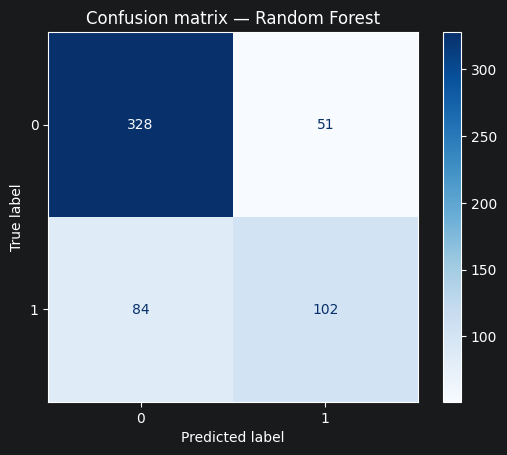

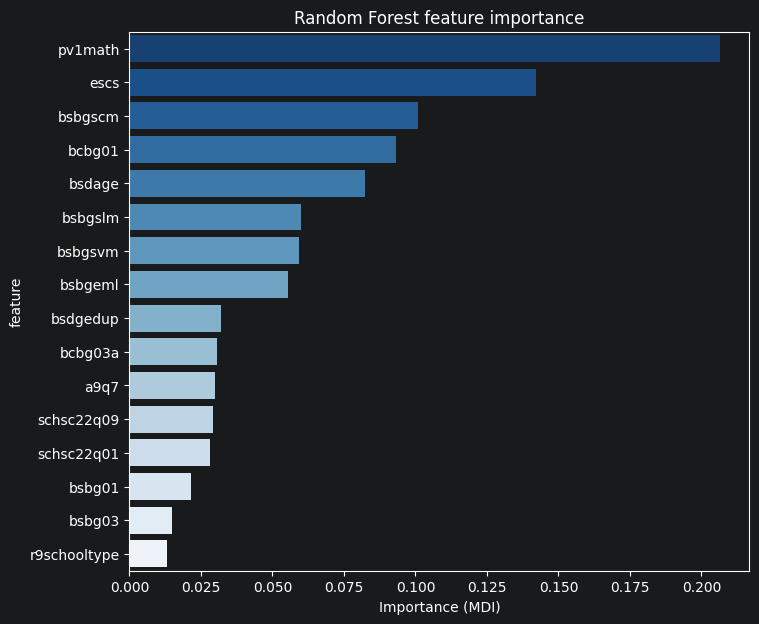

In [15]:
rf_best = RandomForestClassifier(**best_params_rf, random_state=SEED, n_jobs=-1).fit(X_train, y_train)
res_rf = fit_metrics(rf_best, X_train, y_train, X_test, y_test, 'Random Forest')
imp_rf = plot_importance(rf_best, X.columns, 'Random Forest feature importance')

#train 1.0, но test 0.761 - для леса эта нормальная ситуация из-за особенностей его работы - деревья обучаются на выборках с повторами, из-за этого отдельные деревья переобучаются и запоминают свои выборки

### Task 4.3. Compare feature importance: DT vs RF

Look at the feature-importance bar plots from Task 3.4 (DT) and Task 4.2 (RF).

- Print the **top-3 features by importance** from `dt_best`.
- Print the **top-3 features by importance** from `rf_best`.
- In 1–2 sentences in the markdown cell below, comment: are the top-3 sets the same? If they differ, name **at least one feature** that ranks top in one model but not the other. (You don't need to explain *why* the difference exists — just observe what is true on your data.)

In [16]:
top3_dt = imp_dt.head(3)['feature'].tolist()
top3_rf = imp_rf.head(3)['feature'].tolist()
print("DT top-3:", top3_dt)
print("RF top-3:", top3_rf)
print("Same set:", set(top3_dt) == set(top3_rf))
print("Only in DT top-3:", set(top3_dt) - set(top3_rf))
print("Only in RF top-3:", set(top3_rf) - set(top3_dt))

# DT и RF имеют 3 одинаковых топ признака - pv1math, ecs, bsgscm

DT top-3: ['pv1math', 'escs', 'bsbgscm']
RF top-3: ['pv1math', 'escs', 'bsbgscm']
Same set: True
Only in DT top-3: set()
Only in RF top-3: set()


**Your answer (1–2 sentences):**

*DT and RF have no differences in top features*

### Task 4.4. Compare DT vs RF (mini-table)

Build a small DataFrame with rows = [Decision Tree, Random Forest] and columns = [train accuracy, test accuracy, test `SCORING`]. Display it.

In [17]:
tbl_dt_rf = pd.DataFrame([res_dt, res_rf]).set_index('model')
tbl_dt_rf.round(4)
#лес обогнал дерево по f1

,train_acc,test_acc,test_f1
model,,,
Decision Tree,0.7374,0.7221,0.5813
Random Forest,1.0000,0.7611,0.6018


## Task 5. Gradient Boosting + Voting ensemble + final comparison (0–2 scores)

### Task 5.1. Gradient Boosting + search + fit

Use `GradientBoostingClassifier(random_state=SEED)`. Search:
- `n_estimators` — one of `[50, 100, 200, 400]`
- `max_depth` — one of `[2, 3, 4, 5]`
- `learning_rate` — one of `[0.01, 0.05, 0.1, 0.2]`
- `subsample` — one of `[0.6, 0.8, 1.0]`

`RandomizedSearchCV` with `n_iter=20`, `cv=5`, `scoring=SCORING`, `n_jobs=-1`, `random_state=SEED`. Print `best_params_` and best CV score.

Then refit `GradientBoostingClassifier(**best_params_gbm, random_state=SEED)` on `X_train`, save as `gbm_best`, and call `fit_metrics(gbm_best, X_train, y_train, X_test, y_test, 'Gradient Boosting')`.

> See `L5_Ensembles.ipynb` for the canonical pattern: build a `param_distributions` dict mapping each hyper-parameter name to a list/range of candidates, wrap it in `RandomizedSearchCV(estimator, param_distributions=..., n_iter=..., cv=..., scoring=..., random_state=...)`, call `.fit(X_train, y_train)`, then read `.best_params_` and `.best_score_`.*

GBM best params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05}
GBM best CV f1: 0.578
=== Gradient Boosting ===
Train accuracy: 0.866
Test  accuracy: 0.770
              precision    recall  f1-score   support

           0       0.80      0.87      0.84       379
           1       0.68      0.57      0.62       186

    accuracy                           0.77       565
   macro avg       0.74      0.72      0.73       565
weighted avg       0.76      0.77      0.76       565



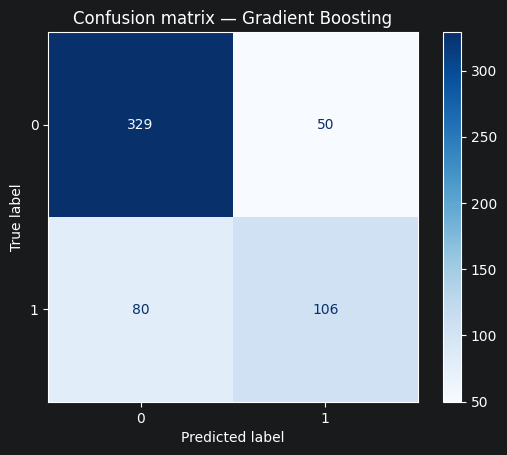

In [18]:
from sklearn.ensemble import GradientBoostingClassifier

param_gbm = {
    'n_estimators':  [50, 100, 200, 400],
    'max_depth':     [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample':     [0.6, 0.8, 1.0],
}
search_gbm = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=SEED),
    param_distributions=param_gbm, n_iter=20, cv=5,
    scoring=SCORING, n_jobs=-1, random_state=SEED)
search_gbm.fit(X_train, y_train)

best_params_gbm = search_gbm.best_params_
print("GBM best params:", best_params_gbm)
print(f"GBM best CV {SCORING}: {search_gbm.best_score_:.3f}")

gbm_best = GradientBoostingClassifier(**best_params_gbm, random_state=SEED).fit(X_train, y_train)
res_gbm = fit_metrics(gbm_best, X_train, y_train, X_test, y_test, 'Gradient Boosting')
#бустинг еще точнее f1 - 0.62, что объясняется его приспособленностью для работы на табличных данных

### Task 5.2. Voting ensemble (soft voting)

Combine the three fitted models from Tasks 3, 4, 5 into a `VotingClassifier(voting='soft', n_jobs=-1)`.

- Construct: `VotingClassifier(estimators=[('dt', dt_best), ('rf', rf_best), ('gbm', gbm_best)], voting='soft', n_jobs=-1)`.
- Fit on `X_train` (note: `VotingClassifier` re-fits the underlying estimators by default; that's fine — they will be re-fit on the same `X_train` with the same `SEED`-derived state).
- Call `fit_metrics(voting, X_train, y_train, X_test, y_test, 'Voting (soft)')`.

=== Voting (soft) ===
Train accuracy: 0.912
Test  accuracy: 0.756
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       379
           1       0.66      0.53      0.59       186

    accuracy                           0.76       565
   macro avg       0.73      0.70      0.71       565
weighted avg       0.75      0.76      0.75       565



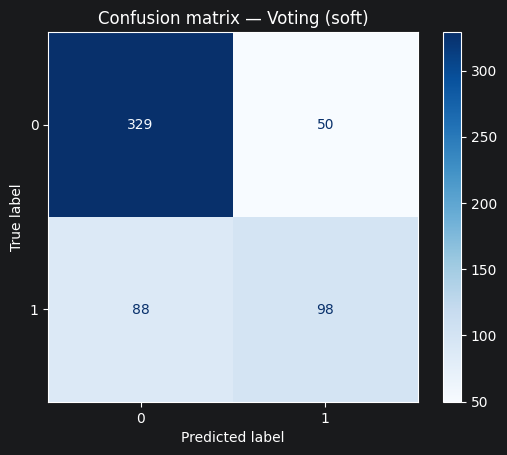

In [19]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[('dt', dt_best), ('rf', rf_best), ('gbm', gbm_best)],
    voting='soft', n_jobs=-1).fit(X_train, y_train)
res_vot = fit_metrics(voting, X_train, y_train, X_test, y_test, 'Voting (soft)')
#voting оказался хуже по f1 из-за того, что в моделях лидируют одни и те же признаки => ошибки моделей (как и сами модели - дерево и его модификации) одинаковы и голосование повторяет общую ошибку

### Task 5.3. Final comparison table

Build a pandas DataFrame with **4 rows** (Decision Tree, Random Forest, Gradient Boosting, Voting (soft)) and **3 columns** (train accuracy, test accuracy, test `SCORING`). Sort by test `SCORING` descending. Display it.

In [20]:
final = (pd.DataFrame([res_dt, res_rf, res_gbm, res_vot])
         .set_index('model')
         .sort_values(f'test_{SCORING}', ascending=False))
final.round(4)
#финальное сравнение показывает закономерные результаты - хуже всего одиночное дерево, voting не дал существенного прироста из-за схожести моделей и ключевых признаков. Лучше всего показал себя градиентный бустинг по причине входных табличных данных

,train_acc,test_acc,test_f1
model,,,
Gradient Boosting,0.8656,0.7699,0.6199
Random Forest,1.0000,0.7611,0.6018
Voting (soft),0.9115,0.7558,0.5868
Decision Tree,0.7374,0.7221,0.5813
